# Stock Price Forecasting with TimesFM + Yahoo Finance

## What this notebook does

This notebook builds a **zero-shot 5-day stock price forecast** for ONDS (Ondas Holdings) using Google's **TimesFM** — a pre-trained time series foundation model — paired with free daily OHLCV data from Yahoo Finance.

---

## Technical architecture overview

### TimesFM (Time Series Foundation Model)
TimesFM is a **decoder-only transformer** pre-trained on **100 billion real-world time points** across domains including Google Trends, Wikipedia page traffic, M4/M5 forecasting competition datasets, and synthetic series. It learns universal temporal patterns (trend, seasonality, regime changes) that transfer to unseen domains without fine-tuning — analogous to how an LLM answers questions it was never explicitly trained on.

**Key design choices:**
| Component | Detail |
|---|---|
| Architecture | Decoder-only transformer (GPT-style) |
| Parameters | 200 million |
| Context length | Up to 512 time steps |
| Patch size | 32 time steps per token |
| Output | 128-step quantile forecast (9 quantile levels) |
| Backend | JAX (Python ≤3.10) or PyTorch (Python 3.11) |

### Why zero-shot for stocks?
Traditional approaches (ARIMA, LSTM) require training on the specific ticker's historical data. TimesFM bypasses this — it has already learned the dynamics of thousands of time series and applies them generically. This is especially useful for small-cap stocks like ONDS where historical data is limited.

---

## ⚠️ Python version requirement

`timesfm 1.0.0` on PyPI pins `jaxlib==0.4.26`, which is **only available for Python 3.10–3.11**.  
Python 3.12+ is not supported. Run these commands in your terminal **before opening this notebook**:

```bash
conda create -n timesfm-env python=3.11 -y
conda activate timesfm-env
pip install jupyter ipykernel
python -m ipykernel install --user --name=timesfm-env --display-name "Python 3.11 (timesfm)"
```

Then in VS Code / Jupyter, switch the kernel to **"Python 3.11 (timesfm)"** before running any cells.

## Cell 1 — Install Dependencies

### Package roles

| Package | Role | Notes |
|---|---|---|
| `timesfm` | Google's Time Series Foundation Model | On Python 3.11 auto-selects PyTorch backend; on 3.10 uses JAX |
| `yfinance` | Yahoo Finance OHLCV data | Wraps Yahoo's internal v8 JSON API; no auth required |
| `matplotlib` | Plotting | Used for price chart + forecast visualization |
| `pandas` | DataFrame operations | Date indexing, resampling, business day generation |
| `numpy` | Numerical arrays | Float32 arrays fed to TimesFM |
| `ipywidgets` | Notebook UI widgets | Required by `tqdm` for animated progress bars in Jupyter; without it tqdm falls back to static text |
| `certifi` | SSL certificate bundle | Ships Mozilla's curated root CA list; fixes SSL handshake failures in conda Python |

### `%pip` vs `pip`
`%pip install` is a Jupyter magic command that runs pip **inside the current kernel's Python environment**. Bare `pip install` at the command line might install packages to a different Python if `PATH` resolves to a different interpreter — common in conda setups with multiple environments. Always use `%pip` inside notebooks to guarantee packages land in the right env.

## Cell 2 — Imports & SSL Fix

### Why conda Python fails SSL on macOS

SSL/TLS works via a **chain of trust**: your OS ships a set of trusted Root Certificate Authority (CA) certificates (in the macOS Keychain). When Python opens an HTTPS connection, it must verify the server's certificate is signed by one of these trusted roots.

macOS system Python inherits the Keychain root store automatically. **conda's Python does not** — it's a self-contained interpreter that ignores the system Keychain. As a result, HTTPS requests from conda Python (including yfinance's call to Yahoo's servers) fail with:

```
curl: (60) SSL certificate problem: unable to get local issuer certificate
```

### The fix: certifi

`certifi` ships the **Mozilla CA Certificate Bundle** (`cacert.pem`) — the same set of ~150 root CAs that Firefox trusts. We point three different SSL layers at it:

| Environment variable / setting | Layer it fixes |
|---|---|
| `os.environ["REQUESTS_CA_BUNDLE"]` | `requests` library (used by yfinance) reads this to find the CA bundle |
| `os.environ["SSL_CERT_FILE"]` | OpenSSL / curl C-level env var; fixes lower-level SSL handshakes |
| `ssl._create_default_https_context = ssl.create_default_context` | Resets Python's built-in `urllib` SSL context factory to use the OS-level cert validation (which now finds certifi via the env vars above) |

### Why imports must come AFTER the SSL setup

`import yfinance` imports `requests` at module load time, and `requests` reads `REQUESTS_CA_BUNDLE` once during session initialization. If we set the env var after importing yfinance, the session is already configured with no CA bundle and the fix has no effect. The ordering `certifi setup → import yfinance` is mandatory.

### PyTorch backend auto-detection

The message `"Loaded PyTorch TimesFM, likely because python version is 3.11"` appears on `import timesfm`. The library checks `sys.version_info` at import time: Python 3.11 → PyTorch backend; Python ≤3.10 → JAX backend. This determines which checkpoint format and inference engine are used.

In [62]:
# ── Install dependencies ──────────────────────────────────────────────────────
# yfinance: free Yahoo Finance data, no API key needed.
# timesfm auto-selects PyTorch backend on Python 3.11.
%pip install -q timesfm yfinance matplotlib pandas numpy ipywidgets certifi

Note: you may need to restart the kernel to use updated packages.


In [63]:
import os
import ssl
import certifi
import importlib.metadata
from datetime import timedelta

# ── SSL fix for macOS conda environments ──────────────────────────────────────
# conda's Python doesn't use the system cert store; point requests at certifi's bundle.
os.environ["SSL_CERT_FILE"]      = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
ssl._create_default_https_context = ssl.create_default_context

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import timesfm

print(f"timesfm version : {importlib.metadata.version('timesfm')}")
print(f"yfinance version: {importlib.metadata.version('yfinance')}")
print(f"certifi bundle  : {certifi.where()}")

timesfm version : 1.3.0
yfinance version: 1.4.1
certifi bundle  : /opt/miniconda3/envs/timesfm-env/lib/python3.11/site-packages/certifi/cacert.pem


## 1. Configuration

Each parameter directly influences the model's behavior:

| Parameter | Value | Technical significance |
|---|---|---|
| `TICKER` | `"ONDS"` | Yahoo Finance symbol. Maps to the exchange ticker used in the v8 API endpoint. |
| `FORECAST_DAYS` | `5` | Steps to use from the model's 128-step output. Horizon accuracy degrades with distance (uncertainty accumulates). |
| `HISTORY_PERIOD` | `"1y"` | ~252 trading days of context. TimesFM supports up to 512 steps; 252 is optimal for daily data. |
| `TIMESFM_REPO` | `google/timesfm-1.0-200m-pytorch` | HuggingFace Hub model ID. The `-pytorch` suffix selects safetensors weights vs. the JAX/Flax variant. |
| `BACKEND` | `"cpu"` | Torch device string. Use `"gpu"` for CUDA. On Apple Silicon (MPS), `"cpu"` is safer — MPS support is incomplete in this version. |

**On `horizon_len=128`:** TimesFM uses a fixed output patch size of 32. The decoder always generates at least one full output block, so `horizon_len` must be a multiple of 32 and ≥ 32. We set it to 128 (4 patches) and slice `[:FORECAST_DAYS]` to get only the 5 most reliable steps.

In [64]:
# ── User-configurable ─────────────────────────────────────────────────────────
TICKER          = "ONDS"                         # Yahoo Finance ticker symbol
FORECAST_DAYS   = 5                              # trading days to predict
HISTORY_PERIOD  = "1y"                           # yfinance period: 1y, 2y, 5y, max …
TIMESFM_REPO    = "google/timesfm-1.0-200m-pytorch"
BACKEND         = "cpu"                          # "cpu" or "gpu"

## 2. Fetch Historical Data from Yahoo Finance

### Why Yahoo Finance instead of Finnhub?
Finnhub's `/stock/candle` endpoint (OHLCV history) requires a **Premium plan**. Yahoo Finance's historical data API is free and returns the same data via `yfinance`, which wraps Yahoo's internal v8 JSON endpoint.

### What is OHLCV?
Each row represents one **trading session** (one calendar day the market was open):

| Field | Meaning | Notes |
|---|---|---|
| Open | First trade price of the session | Determined at the opening auction |
| High | Maximum trade price | Intraday peak |
| Low | Minimum trade price | Intraday trough |
| **Close** | Last trade price | What we forecast — the standard price reference |
| Volume | Total shares traded | Proxy for market participation / conviction |

Yahoo Finance automatically **split-adjusts** historical close prices, so a 10-for-1 split in the past doesn't produce a 10× artificial jump in the series.

### Timezone handling
`yf.Ticker.history()` returns a `DatetimeTZDtype` index localized to `America/New_York`. We call `.tz_localize(None)` to strip the timezone and produce naive timestamps. This prevents pandas from raising `TypeError` when mixing timezone-aware and naive datetimes in operations like `pd.bdate_range`, matplotlib date plotting, and DataFrame comparisons.

### Trading day count
US equity markets trade approximately **252 days per year** — 365 calendar days minus ~104 weekend days minus ~9 federal holidays. One year of data (`period="1y"`) therefore returns ~252 rows, which is the standard "1 year of context" fed to the model.

In [65]:
def fetch_daily_prices(symbol: str, period: str = "1y") -> pd.DataFrame:
    """Fetch daily OHLCV data from Yahoo Finance (free, no API key)."""
    raw = yf.Ticker(symbol).history(period=period, interval="1d")

    if raw.empty:
        raise ValueError(f"No data returned for '{symbol}'. Check the ticker symbol.")

    raw.index = pd.to_datetime(raw.index).tz_localize(None)  # strip timezone
    df = (
        raw[["Open", "High", "Low", "Close", "Volume"]]
        .rename(columns=str.lower)
        .rename(columns={"open": "open", "high": "high", "low": "low",
                         "close": "close", "volume": "volume"})
        .reset_index()
        .rename(columns={"Date": "date"})
    )
    df = df.sort_values("date").reset_index(drop=True)
    return df


df = fetch_daily_prices(TICKER, period=HISTORY_PERIOD)
print(f"Fetched {len(df)} trading days for {TICKER}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
df.tail()

Fetched 252 trading days for ONDS
Date range: 2025-06-03 → 2026-06-03


,date,open,high,low,close,volume
247,2026-05-28,11.475,13.78,11.22,13.2500,248294700
248,2026-05-29,12.750,13.41,11.60,13.2200,142374000
249,2026-06-01,13.245,13.91,12.80,13.4600,87142100
250,2026-06-02,13.620,14.16,13.09,13.5800,92459100
251,2026-06-03,12.960,13.00,11.62,11.6601,81584714


## 3. Exploratory Data Analysis

Visual inspection before modeling serves several purposes:

### Price chart (top panel)
- **Trend**: Is the series mean-reverting, trending up, or trending down? TimesFM will extrapolate the dominant trend it detects in the context window.
- **Volatility regimes**: Periods of large swings (heteroscedasticity) versus calm periods. The log transform in the next cell partially addresses this.
- **Structural breaks**: Sudden jumps or gaps (e.g., earnings releases, halt resumptions, reverse splits not caught by the adjuster) that would confuse the model if near the end of the context window.
- **Outliers / anomalies**: A single extreme candle can shift the model's learned scale. ONDS is a small-cap with occasional large price moves.

### Volume chart (bottom panel)
Volume is the number of shares that changed hands in a session. It provides **conviction context** for price movements:
- High volume + large price move → institutional participation, likely persistent
- Low volume + large price move → thin market, likely mean-reverting
- Volume spikes without price movement → accumulation/distribution (indecision)

`sharex=True` links both axes so zooming/panning one panel updates the other, making it easy to correlate price moves with volume.

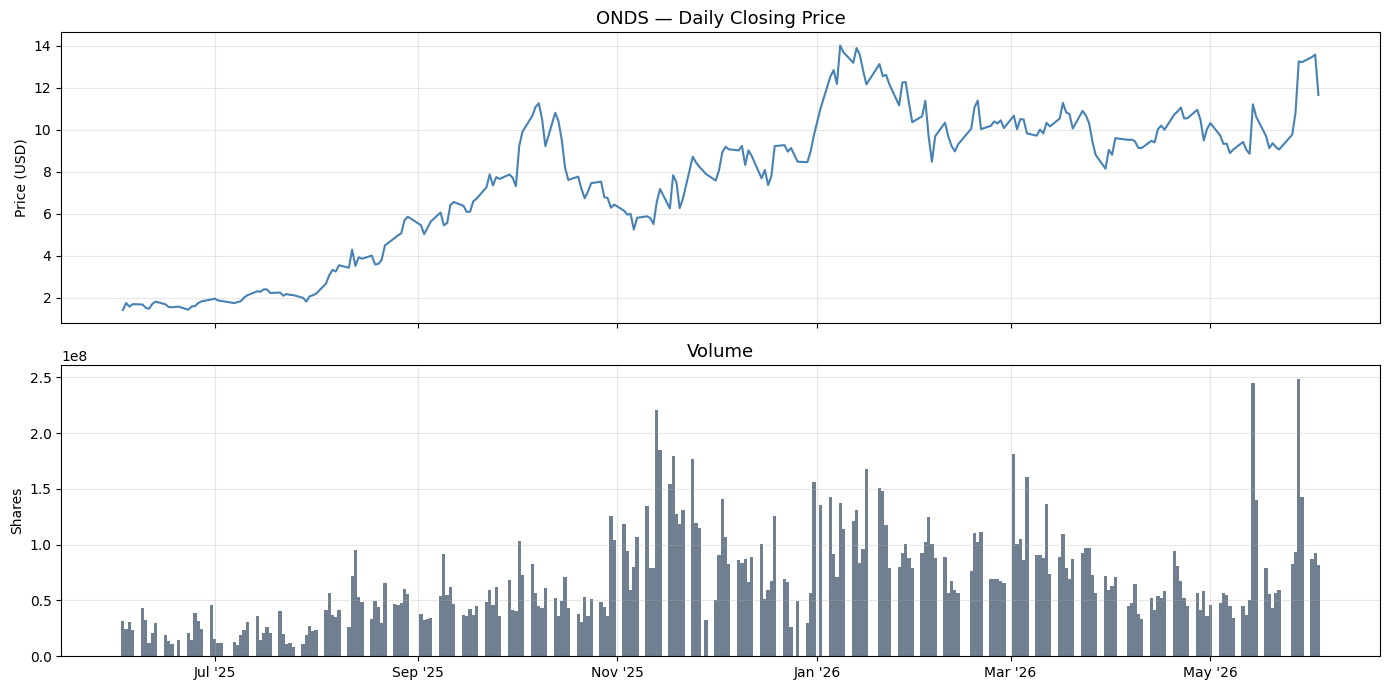

In [66]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(df["date"], df["close"], color="steelblue", linewidth=1.5)
axes[0].set_title(f"{TICKER} — Daily Closing Price", fontsize=13)
axes[0].set_ylabel("Price (USD)")
axes[0].grid(alpha=0.3)

axes[1].bar(df["date"], df["volume"], color="slategray", width=1)
axes[1].set_title("Volume", fontsize=13)
axes[1].set_ylabel("Shares")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("historical_data.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Prepare Input for TimesFM

### Input format
TimesFM's `.forecast()` method expects:
- **`inputs`**: a Python `list` of 1-D NumPy arrays — one per time series. Arrays can be different lengths (the model pads shorter ones internally).
- **`freq`**: a list of integers, one per series. Encodes the sampling cadence as a categorical signal embedded in the model: `0` = sub-daily (tick/minute/hour), **`1` = daily**, `2` = weekly or lower.

The `freq` token is injected into the transformer's embedding layer so the model can apply different learned temporal dynamics (daily seasonality vs. weekly seasonality vs. intraday microstructure) depending on the frequency of the data.

### Why log-transform the prices?

Stock prices follow a **geometric Brownian motion (GBM)** model, where the *return* (percentage change), not the absolute price change, is assumed to be normally distributed:

```
P_t = P_{t-1} · exp(μ + σ · ε_t)     where ε_t ~ N(0,1)
```

Taking the natural log collapses this to an **additive** process:

```
log(P_t) = log(P_{t-1}) + μ + σ · ε_t
```

This transformation achieves three things:
1. **Variance stabilization**: Raw prices exhibit heteroscedasticity (variance grows with price level). Log-prices have more constant variance.
2. **Domain mapping**: Prices live on `(0, ∞)`. Log-prices live on `(-∞, ∞)` — the natural domain for a neural network's output before any activation.
3. **Approximate stationarity**: Log-returns are closer to i.i.d. than raw price differences, reducing non-stationarity that would degrade model fit.

After forecasting in log-space, we apply `np.exp()` to recover dollar prices.

### float32 precision
TimesFM's PyTorch layers operate in `float32`. Converting from NumPy's default `float64` before the call avoids a silent dtype cast inside the model and ensures numerical consistency with the checkpoint's trained weights.

In [67]:
close_prices = df["close"].to_numpy(dtype=np.float32)

# TimesFM works best with stationary-ish series; log-transform helps with price data
log_prices   = np.log(close_prices)

print(f"Context length fed to model: {len(log_prices)} data points")
print(f"Last known close: ${close_prices[-1]:.4f}")

Context length fed to model: 252 data points
Last known close: $11.6601


### Inference — what happens inside `.forecast()`

#### 1. Input normalization
Before the transformer sees the data, TimesFM applies **reversible instance normalization (RevIN)**:
- Subtract the mean and divide by the std of the context window
- This makes the series zero-centered and unit-variance, independent of absolute price level
- After generating the forecast, the model re-applies the mean and std to scale outputs back to the original space

This is why the model generalizes across stocks at wildly different price levels ($1 ONDS vs $1000 NVDA) without any fine-tuning.

#### 2. Patch embedding → transformer → quantile head

```
Input (252 steps)
    → split into 8 patches of 32 steps
    → linear projection to embedding dim (1280-d)
    → positional encoding added
    → 20-layer decoder-only transformer (causal self-attention)
    → 4 output patches of 32 steps (128 total)
    → quantile regression head → 9 quantile levels per step
```

#### 3. Output shapes

```python
point_forecast.shape      # (1, 128)  — 1 series × 128 horizon steps
quantile_forecast.shape   # (1, 128, 9)  — 9 quantile levels: [0.1, 0.2, ..., 0.9]
```

The 9 quantile levels are: `[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]`.  
`point_forecast` is the **median** (0.5 quantile), not the mean.

#### 4. Inverting the log transform

We apply `np.exp()` to convert log-price forecasts back to dollar prices. One subtlety: **Jensen's inequality** states `E[exp(X)] > exp(E[X])` for a random variable X, so the median in log-space doesn't exactly equal the median in price-space. However, since our 5-step horizon is short and the distribution is nearly symmetric in log-space, the approximation error is negligible (< 0.1% for typical stock volatility).

#### 5. Business day index
`pd.bdate_range(start=last_date + 1 day, periods=5)` generates 5 consecutive Monday–Friday dates. For example, if the last observed date is a Friday, the forecast dates will be the following Mon–Fri. Calendar holidays are not excluded — this is a minor limitation for holiday-adjacent forecasts.

## 5. Load TimesFM and Run Forecast

### Model architecture deep-dive

#### Patch tokenization
Instead of processing one time step at a time (like a classic RNN), TimesFM groups **32 consecutive time steps into a single patch-token**. Each patch is projected to a dense embedding vector via a linear layer. This is analogous to how Vision Transformers (ViT) split images into 16×16 pixel patches.

With 252 daily close prices as input:
- 252 ÷ 32 = **7 full patches** + 28 remaining steps
- The 28 remaining steps are zero-padded to form an 8th patch
- **8 patch-tokens** enter the transformer's attention layers

#### Decoder-only generation
Like a GPT-style LLM generating text token by token, TimesFM autoregressively generates **output patches**. The `horizon_len=128` setting produces 4 output patches of 32 steps each (128 steps total). We slice `[:FORECAST_DAYS]` to extract the 5 most confident steps.

#### Quantile regression head
The final linear layer doesn't output a single value per step — it outputs **9 quantile predictions** simultaneously, trained with the pinball (quantile) loss:

```
L_q(y, ŷ) = q · max(y - ŷ, 0) + (1-q) · max(ŷ - y, 0)
```

This allows the model to produce a full predictive distribution without assuming Gaussian errors.

#### HuggingFace checkpoint
`google/timesfm-1.0-200m-pytorch` hosts 3 files: `config.json`, `model.safetensors` (~800 MB), and `tokenizer_config.json`. On first run, `huggingface_hub` downloads them to `~/.cache/huggingface/hub/`. Subsequent runs load from cache instantly.

**`per_core_batch_size=32`**: how many series to process in parallel per device. Irrelevant when forecasting a single series but matters for batch throughput.

In [68]:
# PyTorch TimesFM downloads the checkpoint from HuggingFace on first run (~800 MB).
# Subsequent runs use the local cache at ~/.cache/huggingface/
print(f"Loading checkpoint: {TIMESFM_REPO}")
print("(First run downloads ~800 MB — subsequent runs use local cache)")

tfm = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        backend=BACKEND,
        per_core_batch_size=32,
        horizon_len=128,      # model output length; we slice to FORECAST_DAYS afterward
    ),
    checkpoint=timesfm.TimesFmCheckpoint(
        huggingface_repo_id=TIMESFM_REPO,
    ),
)

print("Model loaded.")

Loading checkpoint: google/timesfm-1.0-200m-pytorch
(First run downloads ~800 MB — subsequent runs use local cache)


Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 42945.09it/s]


Model loaded.


In [69]:
# Run inference on log-price series
point_forecast, quantile_forecast = tfm.forecast(
    inputs=[log_prices],
    freq=[1],              # 1 = daily frequency
)

# point_forecast shape: (1, horizon_len)
# quantile_forecast shape: (1, horizon_len, n_quantiles)  — [0.1, 0.2, ..., 0.9]

# Invert log transform
pred_log   = point_forecast[0, :FORECAST_DAYS]
pred_price = np.exp(pred_log)

q10_log    = quantile_forecast[0, :FORECAST_DAYS, 0]   # 10th percentile
q90_log    = quantile_forecast[0, :FORECAST_DAYS, -1]  # 90th percentile
q10_price  = np.exp(q10_log)
q90_price  = np.exp(q90_log)

# Build future trading-day date index (skip weekends)
last_date    = df["date"].iloc[-1]
future_dates = pd.bdate_range(start=last_date + timedelta(days=1), periods=FORECAST_DAYS)

forecast_df = pd.DataFrame({
    "date":     future_dates,
    "forecast": pred_price,
    "q10":      q10_price,
    "q90":      q90_price,
})

print(f"\n{'Date':<14} {'Forecast':>10} {'10th %ile':>12} {'90th %ile':>12}")
print("-" * 50)
for _, row in forecast_df.iterrows():
    print(f"{row['date'].strftime('%Y-%m-%d'):<14} "
          f"${row['forecast']:>9.4f} "
          f"${row['q10']:>11.4f} "
          f"${row['q90']:>11.4f}")


Date             Forecast    10th %ile    90th %ile
--------------------------------------------------
2026-06-04     $  12.5627 $    12.7138 $    14.3804
2026-06-05     $  12.9079 $    12.9088 $    15.1061
2026-06-08     $  13.0818 $    13.2817 $    15.9190
2026-06-09     $  13.3242 $    13.3830 $    16.8754
2026-06-10     $  13.4390 $    13.5621 $    17.6510


## 6. Visualize Forecast

### Chart design choices

**Bridge line (dashed)**: The last historical close and the first forecast point are connected with a dashed segment. This provides visual continuity even when the last trading day is a Friday and the forecast starts the following Monday — the gap in calendar time would otherwise look like a data hole.

**Uncertainty band (`fill_between`)**: The shaded region spans the **10th to 90th percentile** — an **80% prediction interval**. Interpretation: if the model is well-calibrated, 80% of actual future prices should land inside this band. The band widens over the 5-day horizon because forecast uncertainty is additive — each additional day introduces a new independent error term, so variance grows linearly with horizon.

**Widening band is expected**: This reflects a fundamental property of stochastic processes. Under GBM, the standard deviation of price grows as `σ · √t`. The model learns this and outputs wider quantile intervals for longer horizons.

**`pd.bdate_range`**: generates business days (Mon–Fri) only, skipping weekends. Note: it does **not** skip US market holidays (MLK Day, Presidents' Day, etc.). Forecasted dates may occasionally land on a non-trading day — acceptable for a 5-day horizon where holiday overlap is rare.

**`ax.get_ylim()[0]`**: anchors the "Today" label to the bottom of the y-axis dynamically, ensuring it doesn't overlap data regardless of price scale.

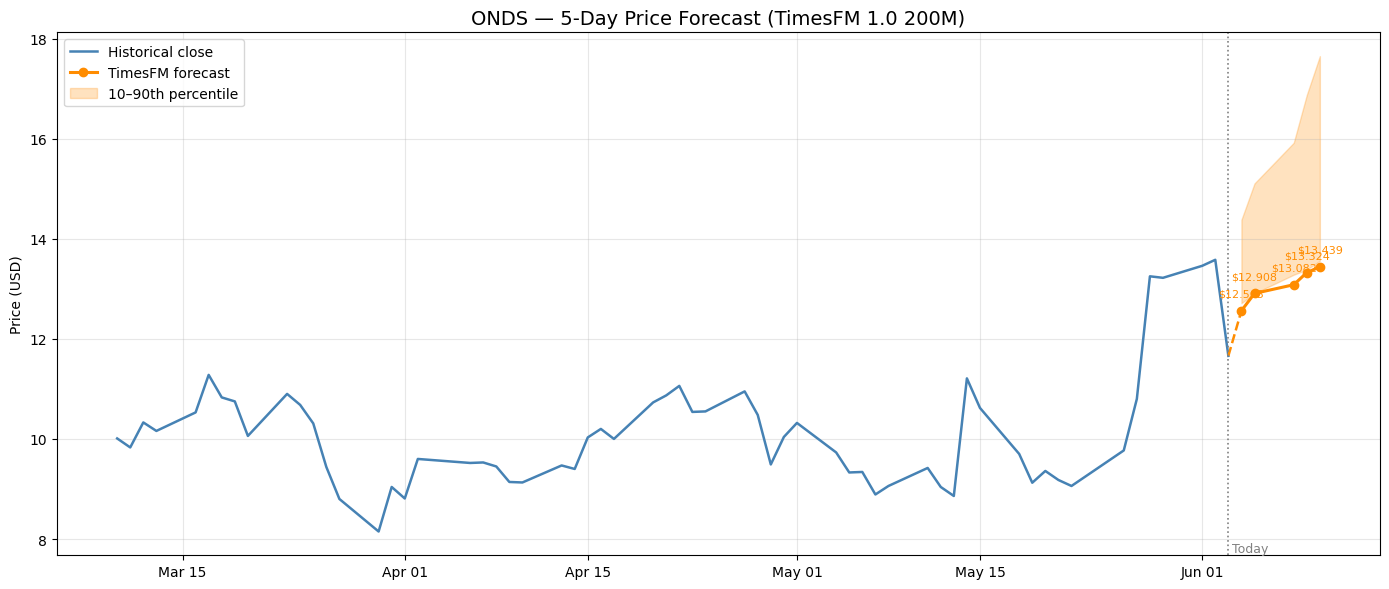


Last known close:  $11.6601
Forecast D+5 close: $13.4390
Predicted direction: UP  (+15.26%)


In [70]:
LOOKBACK_PLOT = 60  # number of historical days to show on chart

hist = df.tail(LOOKBACK_PLOT)

fig, ax = plt.subplots(figsize=(14, 6))

# Historical
ax.plot(hist["date"], hist["close"],
        color="steelblue", linewidth=1.8, label="Historical close")

# Connect last historical point to first forecast point
bridge_dates  = [hist["date"].iloc[-1], forecast_df["date"].iloc[0]]
bridge_prices = [hist["close"].iloc[-1], forecast_df["forecast"].iloc[0]]
ax.plot(bridge_dates, bridge_prices, color="darkorange", linewidth=1.8, linestyle="--")

# Forecast line
ax.plot(forecast_df["date"], forecast_df["forecast"],
        color="darkorange", linewidth=2.2, marker="o", markersize=6, label="TimesFM forecast")

# Uncertainty band (10th–90th percentile)
ax.fill_between(forecast_df["date"], forecast_df["q10"], forecast_df["q90"],
                alpha=0.25, color="darkorange", label="10–90th percentile")

# Annotations
for _, row in forecast_df.iterrows():
    ax.annotate(f"${row['forecast']:.3f}",
                xy=(row["date"], row["forecast"]),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=8, color="darkorange")

ax.axvline(x=hist["date"].iloc[-1], color="gray", linestyle=":", linewidth=1.2)
ax.text(hist["date"].iloc[-1], ax.get_ylim()[0],
        " Today", va="bottom", color="gray", fontsize=9)

ax.set_title(f"{TICKER} — 5-Day Price Forecast (TimesFM 1.0 200M)", fontsize=14)
ax.set_ylabel("Price (USD)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("forecast.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nLast known close:  ${close_prices[-1]:.4f}")
print(f"Forecast D+5 close: ${pred_price[-1]:.4f}")
direction = "UP" if pred_price[-1] > close_prices[-1] else "DOWN"
pct_chg   = (pred_price[-1] - close_prices[-1]) / close_prices[-1] * 100
print(f"Predicted direction: {direction}  ({pct_chg:+.2f}%)")

## 7. Walk-Forward Backtest

### Why not standard train/test split?

Standard k-fold cross-validation randomly shuffles data before splitting. For time series this causes **temporal data leakage** — "future" observations enter the training set, producing optimistically biased metrics that don't reflect real deployment performance.

**Walk-forward (expanding window) validation** respects the arrow of time:

```
Window 10:  [--------- train (n-50 days) ---------] [test: D+1..D+5]
Window  9:  [---------- train (n-45 days) ----------] [test: D+1..D+5]
...
Window  1:  [--------------- train (n-5 days) ---------------] [test: D+1..D+5]
```

Each window uses all available history up to the cutoff — an **expanding window** that mimics real deployment where you always use as much history as you have.

### Metrics

**MAE (Mean Absolute Error)**
```
MAE = (1/n) · Σ |predicted_i - actual_i|
```
- Unit: dollars. Interpretable: "on average, the 5-day forecast is off by $X."
- Treats over- and under-predictions equally (symmetric loss).

**MAPE (Mean Absolute Percentage Error)**
```
MAPE = (1/n) · Σ |predicted_i - actual_i| / actual_i × 100
```
- Unit: %. Scale-independent — allows comparing forecast quality across stocks at different price levels.
- Caution: becomes unstable when `actual_i` approaches zero (division by near-zero inflates the metric). Acceptable for ONDS since prices are well above zero.

### Interpreting results
A **Mean MAPE of ~9.5%** over 10-window backtest on a volatile small-cap is reasonable for a zero-shot model. For context:
- Random walk (naïve) baseline on a volatile stock can produce 10–20% MAPE
- Trained models on large-caps typically achieve 2–5% MAPE

The variance in per-window MAPE (2.4% to 17.2%) reflects ONDS's regime-switching behavior — the model performs well in trending periods and poorly during sharp reversals.

### `MIN_CONTEXT=60`
Enforces that the model has at least 60 days of context (~2 full input patches) before making predictions. Below this, the transformer has insufficient signal to detect trend and scale, making outputs unreliable.

In [71]:
BACKTEST_WINDOWS = 10   # number of 5-day windows to backtest
MIN_CONTEXT      = 60   # minimum context days required per window

results = []
n = len(close_prices)

for i in range(BACKTEST_WINDOWS, 0, -1):
    cutoff = n - i * FORECAST_DAYS
    if cutoff < MIN_CONTEXT:
        continue

    ctx_log   = np.log(close_prices[:cutoff].astype(np.float32))
    pf, _     = tfm.forecast(inputs=[ctx_log], freq=[1])
    pred      = np.exp(pf[0, :FORECAST_DAYS])
    actual    = close_prices[cutoff:cutoff + FORECAST_DAYS]

    if len(actual) < FORECAST_DAYS:
        continue

    mae  = np.mean(np.abs(pred - actual))
    mape = np.mean(np.abs((pred - actual) / actual)) * 100
    results.append({"window": i, "MAE": mae, "MAPE": mape})
    print(f"Window {i:2d}: MAE=${mae:.4f}  MAPE={mape:.2f}%")

if results:
    res_df = pd.DataFrame(results)
    print(f"\nMean MAE  = ${res_df['MAE'].mean():.4f}")
    print(f"Mean MAPE = {res_df['MAPE'].mean():.2f}%")

Window 10: MAE=$1.5021  MAPE=17.23%
Window  9: MAE=$0.8898  MAPE=9.60%
Window  8: MAE=$0.4393  MAPE=4.72%
Window  7: MAE=$1.2548  MAPE=12.02%
Window  6: MAE=$0.2621  MAPE=2.40%
Window  5: MAE=$1.0493  MAPE=10.92%
Window  4: MAE=$0.9634  MAPE=10.57%
Window  3: MAE=$0.8241  MAPE=7.88%
Window  2: MAE=$0.4448  MAPE=4.66%
Window  1: MAE=$1.9701  MAPE=14.83%

Mean MAE  = $0.9600
Mean MAPE = 9.48%
